# Pipeline v6 — Approche jointe + pont sémantique

## Pourquoi v4 et v5 plafonnent à ~0.57 F1

```
v4/v5 : img_feats → projection → v_img ──┐
                                          ├── angle/distance → classifieur
        txt_feats → projection → v_txt ──┘
```

**Problème** : HOG/LBP/TF-IDF sont des features *intra-modalité*.
Ils décrivent l'image et le texte séparément, mais ne savent pas
si 'plage' dans le texte correspond à 'sable + eau' dans l'image.
Aucune projection linéaire ne peut créer cette correspondance —
elle n'est tout simplement pas encodée dans les features.

## Stratégie v6 : 3 blocs complémentaires

```
BLOC A — Classique joint (le plus fort sans sémantique)
  concat(img_pca, txt_pca) → RandomForest/GBM
  On donne les deux modalités AU MÊME modèle → il apprend
  les interactions img×txt directement.

BLOC B — Pont sémantique lexical (sans réseau)
  Extraire les OBJETS et SCÈNES du texte (NER léger par regex/dict)
  Extraire les COULEURS dominantes de l'image
  Construire des features CROSS-MODALES explicites :
    - 'le texte parle de ciel bleu' × 'la partie haute de l'image est bleue'
    - 'le texte parle de foule' × 'nb régions segmentées > seuil'
    - 'le texte parle de nuit' × 'luminosité moyenne < seuil'

BLOC C — Représentation interaction (produit, ratio par dim)
  Au lieu de mesurer l'angle entre v_img et v_txt,
  on donne [v_img ⊗ v_txt, v_img - v_txt, v_img + v_txt]
  comme features au classifieur → il apprend QUELLES DIMENSIONS
  doivent être alignées vs divergentes.
```

In [1]:
!pip install opencv-python scikit-image vaderSentiment joblib --quiet


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
# ═══════════════════════════════════════════════════════════
# Cell 2 — Imports
# ═══════════════════════════════════════════════════════════
import os, warnings, time, copy, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

from nltk.stem import PorterStemmer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, TfidfVectorizer
from sklearn.decomposition import TruncatedSVD, PCA
from sklearn.preprocessing import StandardScaler, normalize as sk_normalize
from sklearn.feature_selection import VarianceThreshold
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, roc_auc_score, precision_recall_curve, roc_curve
)
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.utils import shuffle
from sklearn.utils.class_weight import compute_class_weight
from scipy.stats import entropy as scipy_entropy
from scipy.spatial.distance import cosine
from skimage.feature import hog, local_binary_pattern
from skimage.color import rgb2gray
from skimage import io, transform
from skimage.filters import threshold_otsu
from joblib import Parallel, delayed, Memory
import multiprocessing

N_JOBS = max(1, multiprocessing.cpu_count() - 1)
memory = Memory('./joblib_cache_v6', verbose=0)
TOKEN_RE = re.compile(r"[a-zA-Z']+")
stemmer  = PorterStemmer()
STOP     = set(ENGLISH_STOP_WORDS)

def tokenize(text): return TOKEN_RE.findall(text.lower())
def preprocess(text):
    return ' '.join(stemmer.stem(t) for t in tokenize(text)
                    if t not in STOP and len(t) > 1)

try:
    from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
    VADER_OK = True; vader = SentimentIntensityAnalyzer()
except ImportError:
    VADER_OK = False

warnings.filterwarnings('ignore')
print(f'Imports OK — {N_JOBS} workers')

Imports OK — 7 workers


In [3]:
# ═══════════════════════════════════════════════════════════
# Cell 3 — Données
# ═══════════════════════════════════════════════════════════
DATA_DIR = '../data/processed'

def load_split(split):
    texts, paths, labels = [], [], []
    for label, cat in enumerate(['incoherent', 'coherent']):
        folder = os.path.join(DATA_DIR, split, cat)
        if not os.path.exists(folder): continue
        for f in sorted(os.listdir(folder)):
            if f.endswith('.txt'):
                with open(os.path.join(folder, f), encoding='utf-8') as fh:
                    texts.append(fh.read().strip())
                paths.append(os.path.join(folder, f.replace('.txt', '.jpg')))
                labels.append(label)
    return shuffle(np.array(texts), np.array(paths), np.array(labels), random_state=42)

t_train, p_train, y_train = load_split('train')
t_val,   p_val,   y_val   = load_split('validation')
t_test,  p_test,  y_test  = load_split('test')
print(f'Train {len(t_train)} | Val {len(t_val)} | Test {len(t_test)}')
cw = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
CLASS_WEIGHT = {0: cw[0], 1: cw[1]}

Train 7000 | Val 1500 | Test 1500


In [4]:
# ═══════════════════════════════════════════════════════════
# Cell 4 — Features image
# ═══════════════════════════════════════════════════════════
IMG_SIZE = (192, 192)
GRID_N   = 3

def load_img(path):
    img = io.imread(path)
    if img.ndim == 2:     img = np.stack([img]*3, -1)
    if img.shape[2] == 4: img = img[:,:,:3]
    img = (transform.resize(img, IMG_SIZE, anti_aliasing=True)*255).astype(np.uint8)
    return img, rgb2gray(img), cv2.cvtColor(img, cv2.COLOR_RGB2HSV)

def zone_feat(zg, zr, zh):
    h = hog(zg, orientations=8, pixels_per_cell=(8,8), cells_per_block=(2,2), feature_vector=True)
    hsv_f = np.concatenate([
        np.histogram(zh[:,:,c], bins=16, range=r)[0].astype(float)
        for c,r in [(0,(0,180)),(1,(0,256)),(2,(0,256))]])
    hsv_f /= (hsv_f.sum()+1e-8)
    lbp = local_binary_pattern(zg, 16, 2, method='uniform')
    lbp_f = np.histogram(lbp, bins=18, range=(0,18))[0].astype(float)
    lbp_f /= (lbp_f.sum()+1e-8)
    return np.concatenate([h, hsv_f, lbp_f, [zg.mean(), zg.std()]])

def sal_map(gray):
    g = (gray*255).astype(np.float32)
    fft = np.fft.fft2(g)
    la = np.log(np.abs(fft)+1e-8)
    sm = cv2.filter2D(la,-1,np.ones((3,3),np.float32)/9)
    rec = np.fft.ifft2(np.exp(la-sm+1j*np.angle(fft))).real
    s = cv2.GaussianBlur(rec**2,(9,9),2.5)
    return (s-s.min())/(s.max()-s.min()+1e-8)

@memory.cache
def img_feats(path):
    try:
        img, gray, hsv = load_img(path)
        h, w = img.shape[:2]
        zh, zw, hh = h//GRID_N, w//GRID_N, h//2
        zf = np.concatenate([zone_feat(
            gray[r*zh:(r+1)*zh,c*zw:(c+1)*zw],
            img [r*zh:(r+1)*zh,c*zw:(c+1)*zw],
            hsv [r*zh:(r+1)*zh,c*zw:(c+1)*zw])
            for r in range(GRID_N) for c in range(GRID_N)])
        canny = cv2.Canny((gray*255).astype(np.uint8),50,150).astype(float)/255
        sal   = sal_map(gray)
        otsu  = (gray > threshold_otsu(gray)).astype(float)
        def zm(a): return a[:GRID_N*zh,:GRID_N*zw].reshape(GRID_N,zh,GRID_N,zw).mean(axis=(1,3)).ravel()
        cn = np.argwhere(canny>0.5)
        cy = cn[:,0].mean()/h if len(cn)>0 else 0.5
        cx = cn[:,1].mean()/w if len(cn)>0 else 0.5
        sc = np.array([
            cy, cx,
            canny[:,:w//2].mean()-canny[:,w//2:].mean(),
            canny[:hh,:].mean()-canny[hh:,:].mean(),
            hsv[:hh,:,0].mean()/180, hsv[hh:,:,0].mean()/180,
            hsv[:hh,:,1].mean()/255, hsv[hh:,:,1].mean()/255,
            hsv[:,:,2].mean()/255,
            sal.mean(), sal.std(), scipy_entropy(zm(sal)+1e-8),
            canny.mean(), otsu.mean(), gray.mean(), gray.std()
        ])
        hog_g = hog(gray, orientations=9, pixels_per_cell=(16,16),
                    cells_per_block=(2,2), feature_vector=True)
        return np.concatenate([zf, zm(canny), zm(sal), zm(otsu), sc, hog_g])
    except Exception as e:
        return np.zeros(600)

print('Extraction image...')
F_img = {n: np.array(Parallel(n_jobs=N_JOBS)(delayed(img_feats)(p) for p in paths))
         for n, paths in [('train',p_train),('val',p_val),('test',p_test)]}
print(f'  Shape : {F_img["train"].shape}')

Extraction image...


/usr/local/lib/python3.9/site-packages/skimage/feature/texture.py:360: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(
/usr/local/lib/python3.9/site-packages/skimage/feature/texture.py:360: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(
/usr/local/lib/python3.9/site-packages/skimage/feature/texture.py:360: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(
/usr/local/lib/python3.9/

  Shape : (7000, 19123)


In [5]:
# ═══════════════════════════════════════════════════════════
# Cell 5 — Features texte
# ═══════════════════════════════════════════════════════════
tfidf = TfidfVectorizer(max_features=8000, ngram_range=(1,2),
                         sublinear_tf=True, min_df=2,
                         token_pattern=r"[a-zA-Z']+")
T = {}
T['train'] = tfidf.fit_transform([preprocess(t) for t in t_train]).toarray()
T['val']   = tfidf.transform([preprocess(t) for t in t_val]).toarray()
T['test']  = tfidf.transform([preprocess(t) for t in t_test]).toarray()

SKW = ['sky','cloud','tree','grass','water','sea','ocean','mountain','forest','beach',
       'city','street','building','road','car','person','people','crowd','indoor','outdoor',
       'top','bottom','left','right','center','above','below','dark','bright','night','day']

def txt_extras(text):
    toks = set(tokenize(text))
    kw   = np.array([1.0 if w in toks else 0.0 for w in SKW])
    sent = np.zeros(4)
    if VADER_OK:
        s = vader.polarity_scores(text)
        sent = np.array([s['pos'], s['neg'], s['neu'], s['compound']])
    words = tokenize(text)
    stats = np.array([len(words), len(set(words)),
                       np.mean([len(w) for w in words]) if words else 0,
                       len(set(words))/(len(words)+1e-8)])
    return np.concatenate([kw, sent, stats])

F_txt = {}
for n, texts in [('train',t_train),('val',t_val),('test',t_test)]:
    extras = np.array([txt_extras(t) for t in texts])
    F_txt[n] = np.hstack([T[n], extras])
print(f'  Shape texte : {F_txt["train"].shape}')

  Shape texte : (7000, 8039)


In [6]:
# ═══════════════════════════════════════════════════════════
# Cell 6 — BLOC B : Pont sémantique lexical
#
# Features CROSS-MODALES explicites sans réseau de neurones.
# Chaque feature répond à : 'ce que dit le texte correspond-il
# à ce qu'on voit dans l'image ?'
# ═══════════════════════════════════════════════════════════

# Dictionnaire sémantique : concept → couleur/luminosité/texture attendue
SEMANTIC_BRIDGE = {
    # (mots-clés texte, region_image, canal_HSV, valeur_attendue, tolerance)
    # Format : (text_keywords, img_fn_name, expected_direction)
    'sky_concept':   {'words': ['sky','cloud','sun','sunset','sunrise','blue','heaven'],
                       'img_fn': 'top_hue_blue',    'coherent_if': 'high'},
    'nature_concept':{'words': ['tree','grass','forest','green','leaf','leaves','garden'],
                       'img_fn': 'green_ratio',     'coherent_if': 'high'},
    'water_concept': {'words': ['sea','ocean','water','river','lake','wave','beach','surf'],
                       'img_fn': 'blue_saturation', 'coherent_if': 'high'},
    'night_concept': {'words': ['night','dark','darkness','black','moon','star','midnight'],
                       'img_fn': 'brightness',      'coherent_if': 'low'},
    'bright_concept':{'words': ['bright','sun','sunny','daylight','white','light','clear'],
                       'img_fn': 'brightness',      'coherent_if': 'high'},
    'crowd_concept': {'words': ['crowd','people','person','group','team','audience','gathering'],
                       'img_fn': 'edge_density',    'coherent_if': 'high'},
    'empty_concept': {'words': ['empty','alone','lonely','desert','isolated','bare','solitary'],
                       'img_fn': 'edge_density',    'coherent_if': 'low'},
    'city_concept':  {'words': ['city','urban','building','street','road','traffic','downtown'],
                       'img_fn': 'edge_density',    'coherent_if': 'high'},
    'indoor_concept':{'words': ['indoor','inside','room','office','home','interior','wall'],
                       'img_fn': 'top_brightness',  'coherent_if': 'uniform'},
    'red_concept':   {'words': ['red','fire','blood','rose','warm','hot','sunset'],
                       'img_fn': 'red_ratio',       'coherent_if': 'high'},
}

def extract_img_properties(path):
    """Extrait les propriétés visuelles utilisées par le pont sémantique."""
    try:
        img = io.imread(path)
        if img.ndim == 2:     img = np.stack([img]*3,-1)
        if img.shape[2] == 4: img = img[:,:,:3]
        img = (transform.resize(img, IMG_SIZE, anti_aliasing=True)*255).astype(np.uint8)
        gray = rgb2gray(img)
        hsv  = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
        h, w = img.shape[:2]
        hh   = h//2

        # Hue de la partie haute (ciel)
        top_hue   = hsv[:hh,:,0].mean()/180
        top_sat   = hsv[:hh,:,1].mean()/255
        top_val   = hsv[:hh,:,2].mean()/255
        full_val  = hsv[:,:,2].mean()/255
        full_sat  = hsv[:,:,1].mean()/255

        # Ratio couleurs spécifiques
        # Bleu : hue 100-130 (HSV 0-180)
        blue_mask = (hsv[:,:,0] > 100) & (hsv[:,:,0] < 130) & (hsv[:,:,1] > 80)
        blue_ratio = blue_mask.mean()
        top_blue = ((hsv[:hh,:,0] > 100) & (hsv[:hh,:,0] < 130) & (hsv[:hh,:,1] > 80)).mean()

        # Vert : hue 35-85
        green_mask = (hsv[:,:,0] > 35) & (hsv[:,:,0] < 85) & (hsv[:,:,1] > 60)
        green_ratio = green_mask.mean()

        # Rouge : hue 0-15 ou 165-180
        red_mask = ((hsv[:,:,0] < 15) | (hsv[:,:,0] > 165)) & (hsv[:,:,1] > 80)
        red_ratio = red_mask.mean()

        # Densité de bords
        canny = cv2.Canny((gray*255).astype(np.uint8),50,150)
        edge_density = (canny > 0).mean()

        # Uniformité haut vs bas
        brightness_var_top = gray[:hh,:].std()
        brightness_var_bot = gray[hh:,:].std()

        # Nb de régions distinctes (proxy texture complexité)
        otsu = (gray > threshold_otsu(gray)).astype(np.uint8)
        n_components, _ = cv2.connectedComponents(otsu)

        return {
            'top_hue_blue':    top_blue,
            'green_ratio':     green_ratio,
            'blue_saturation': blue_ratio,
            'brightness':      full_val,
            'edge_density':    edge_density,
            'top_brightness':  top_val,
            'red_ratio':       red_ratio,
            'n_regions':       min(n_components/100, 1.0),
            'color_saturation':full_sat,
            'brightness_var':  brightness_var_top,
        }
    except Exception:
        return {k: 0.0 for k in ['top_hue_blue','green_ratio','blue_saturation',
                                   'brightness','edge_density','top_brightness',
                                   'red_ratio','n_regions','color_saturation','brightness_var']}


def extract_semantic_bridge(text, img_props):
    """Feature cross-modale : pour chaque concept, score de cohérence."""
    toks = set(tokenize(text))
    features = []

    for concept_name, concept in SEMANTIC_BRIDGE.items():
        # Score de présence du concept dans le texte [0,1]
        text_score = sum(1 for w in concept['words'] if w in toks) / len(concept['words'])

        # Valeur visuelle correspondante
        img_val = img_props.get(concept['img_fn'], 0.0)

        # Feature de cohérence : text_score × img_val (si coherent_if=high)
        #                        text_score × (1-img_val) (si coherent_if=low)
        if concept['coherent_if'] == 'high':
            coherence_score = text_score * img_val
        elif concept['coherent_if'] == 'low':
            coherence_score = text_score * (1.0 - img_val)
        else:  # uniform
            coherence_score = text_score * (1.0 - abs(img_val - 0.5)*2)

        features.extend([text_score, img_val, coherence_score,
                          text_score * img_val,    # produit
                          abs(text_score - img_val)])  # différence

    # Features globales
    n_concepts_in_text = sum(
        1 for c in SEMANTIC_BRIDGE.values()
        if any(w in toks for w in c['words']))
    features.append(n_concepts_in_text / len(SEMANTIC_BRIDGE))

    return np.array(features)


print('Extraction pont sémantique...')
BRIDGE = {}
for split_name, texts, paths in [
    ('train', t_train, p_train),
    ('val',   t_val,   p_val),
    ('test',  t_test,  p_test)
]:
    img_props_list = Parallel(n_jobs=N_JOBS)(delayed(extract_img_properties)(p) for p in paths)
    bridge_feats = np.array([extract_semantic_bridge(t, ip)
                              for t, ip in zip(texts, img_props_list)])
    BRIDGE[split_name] = bridge_feats
    print(f'  {split_name}: {bridge_feats.shape}  '
          f'(coherent moyen: {bridge_feats[y_train==1 if split_name=="train" else slice(None)].mean():.4f})')

# AUC des features de pont sur le train
from sklearn.metrics import roc_auc_score
print('\nPouvoir discriminant des features de pont (train) :')
n_scalar = 5  # text_score, img_val, coherence_score, produit, diff
concept_names = list(SEMANTIC_BRIDGE.keys())
for k, cname in enumerate(concept_names):
    base = k * n_scalar
    coh_feat = BRIDGE['train'][:, base+2]  # coherence_score
    try:
        auc = roc_auc_score(y_train, coh_feat)
        auc = max(auc, 1-auc)
    except Exception:
        auc = 0.5
    bar = '█' * int((auc-0.5)*200)
    print(f'  {cname:<20} AUC={auc:.4f}  {bar}')

Extraction pont sémantique...
  train: (7000, 51)  (coherent moyen: 0.0976)
  val: (1500, 51)  (coherent moyen: 0.0975)
  test: (1500, 51)  (coherent moyen: 0.0981)

Pouvoir discriminant des features de pont (train) :
  sky_concept          AUC=0.5003  
  nature_concept       AUC=0.5038  
  water_concept        AUC=0.5010  
  night_concept        AUC=0.5003  
  bright_concept       AUC=0.5003  
  crowd_concept        AUC=0.5024  
  empty_concept        AUC=0.5003  
  city_concept         AUC=0.5017  
  indoor_concept       AUC=0.5018  
  red_concept          AUC=0.5032  


In [7]:
# ═══════════════════════════════════════════════════════════
# Cell 7 — Réduction dimensionnelle mémoire-safe
# ═══════════════════════════════════════════════════════════
print('Réduction dimensionnelle...')

vt_i = VarianceThreshold(1e-6)
sc_i = StandardScaler()
Fi = {}
Fi['train'] = sc_i.fit_transform(vt_i.fit_transform(F_img['train']))
for n in ['val','test']:
    Fi[n] = sc_i.transform(vt_i.transform(F_img[n]))

vt_t = VarianceThreshold(1e-6)
sc_t = StandardScaler()
Ft = {}
Ft['train'] = sc_t.fit_transform(vt_t.fit_transform(F_txt['train']))
for n in ['val','test']:
    Ft[n] = sc_t.transform(vt_t.transform(F_txt[n]))

# PCA image (randomized)
K_img = 100
pca_i = PCA(n_components=min(K_img,Fi['train'].shape[1]),
             svd_solver='randomized', random_state=42)
Pi = {n: pca_i.fit_transform(Fi[n]) if n=='train' else pca_i.transform(Fi[n])
       for n in ['train','val','test']}
print(f'  PCA img: {Pi["train"].shape[1]} dims')

# TruncatedSVD texte
K_txt = 100
svd_t = TruncatedSVD(n_components=min(K_txt,Ft['train'].shape[1]), random_state=42)
Pt = {n: svd_t.fit_transform(Ft[n]) if n=='train' else svd_t.transform(Ft[n])
       for n in ['train','val','test']}
print(f'  SVD txt: {Pt["train"].shape[1]} dims')

# Normaliser
for n in ['train','val','test']:
    Pi[n] = sk_normalize(Pi[n])
    Pt[n] = sk_normalize(Pt[n])

Réduction dimensionnelle...
  PCA img: 100 dims
  SVD txt: 100 dims


In [8]:
# ═══════════════════════════════════════════════════════════
# Cell 8 — BLOC C : features d'interaction dim-à-dim
#
# Au lieu de mesurer UN scalaire (angle), on donne au classifieur
# TOUTES les interactions entre dims img et txt :
#   produit   : v_img[k] * v_txt[k]  (alignement par dim)
#   différence: v_img[k] - v_txt[k]  (écart par dim)
#   somme     : v_img[k] + v_txt[k]  (activation commune)
#
# Le classifieur apprend quelles dimensions doivent être
# alignées et lesquelles doivent diverger pour la cohérence.
# ═══════════════════════════════════════════════════════════

def interaction_features(v_img, v_txt):
    eps   = 1e-8
    diff  = v_img - v_txt
    prod  = v_img * v_txt
    sumv  = v_img + v_txt

    ni = np.linalg.norm(v_img)+eps
    nt = np.linalg.norm(v_txt)+eps

    # Scalaires géométriques
    cos_sim  = np.clip(np.dot(v_img,v_txt)/(ni*nt),-1,1)
    angle    = np.arccos(cos_sim)
    d_l2     = np.linalg.norm(diff)
    d_l1     = np.sum(np.abs(diff))
    proj_s   = np.dot(v_txt,v_img)/ni
    orth_n   = np.linalg.norm(v_txt - proj_s*v_img/ni)
    pearson  = np.corrcoef(v_img,v_txt)[0,1] if len(v_img)>2 else 0.0
    pos_align= (prod>0).mean()

    scalars = np.array([
        cos_sim, angle, d_l2, d_l1, proj_s, orth_n,
        pearson, pos_align,
        ni, nt, ni/nt,
        diff.mean(), diff.std(), diff.max(), diff.min(),
        prod.mean(), prod.std(), prod.max(),
        sumv.mean(), sumv.std(),
        (np.sign(v_img)==np.sign(v_txt)).mean(),
    ])
    # Vecteurs dim-à-dim
    return np.concatenate([scalars, prod, diff, sumv])


def build_interaction(Pi_split, Pt_split):
    return np.array(Parallel(n_jobs=N_JOBS, prefer='threads')(
        delayed(interaction_features)(Pi_split[i], Pt_split[i])
        for i in range(len(Pi_split))))

print('Calcul features interaction...')
INT = {n: build_interaction(Pi[n], Pt[n]) for n in ['train','val','test']}
print(f'  Shape interaction : {INT["train"].shape}')

Calcul features interaction...
  Shape interaction : (7000, 321)


In [9]:
# ═══════════════════════════════════════════════════════════
# Cell 9 — Construction des 4 datasets
#
# On teste 4 combinaisons pour identifier la contribution
# de chaque bloc :
#   D1 = interaction seul           (BLOC C)
#   D2 = interaction + pont         (BLOC B+C)
#   D3 = concat(img,txt) joint      (BLOC A)
#   D4 = tout                       (A+B+C)
# ═══════════════════════════════════════════════════════════

sc_int  = StandardScaler()
sc_br   = StandardScaler()
sc_cat  = StandardScaler()

Int = {}
Int['train'] = sc_int.fit_transform(INT['train'])
for n in ['val','test']: Int[n] = sc_int.transform(INT[n])

Br = {}
Br['train'] = sc_br.fit_transform(BRIDGE['train'])
for n in ['val','test']: Br[n] = sc_br.transform(BRIDGE[n])

Cat = {}  # concat brut img + txt (BLOC A)
Cat['train'] = sc_cat.fit_transform(np.hstack([Pi['train'], Pt['train']]))
for n in ['val','test']: Cat[n] = sc_cat.transform(np.hstack([Pi[n], Pt[n]]))

DATASETS = {
    'D1_interaction':       {n: Int[n] for n in ['train','val','test']},
    'D2_interact+pont':     {n: np.hstack([Int[n], Br[n]]) for n in ['train','val','test']},
    'D3_concat_joint':      {n: Cat[n] for n in ['train','val','test']},
    'D4_tout':              {n: np.hstack([Int[n], Br[n], Cat[n]]) for n in ['train','val','test']},
}

for name, ds in DATASETS.items():
    print(f'  {name:<25} train={ds["train"].shape}')

  D1_interaction            train=(7000, 321)
  D2_interact+pont          train=(7000, 372)
  D3_concat_joint           train=(7000, 200)
  D4_tout                   train=(7000, 572)


In [11]:
# ═══════════════════════════════════════════════════════════
# Cell 10 — Entraînement
# ═══════════════════════════════════════════════════════════
CLFS = {
    'LR':   LogisticRegression(C=1.0, max_iter=2000, class_weight='balanced',
                                n_jobs=-1, random_state=42),
    'RF':   RandomForestClassifier(n_estimators=400, class_weight='balanced',
                                    n_jobs=-1, random_state=42),
    'SVM':  CalibratedClassifierCV(
                SVC(kernel='rbf', C=1.0, gamma='scale',
                    class_weight='balanced', random_state=42), cv=3),
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []

print(f'{"Dataset":<26} {"Clf":<6} {"CV-F1":>8} {"±":>5} {"Val-Acc":>8} {"Val-F1":>8}')
print('-'*65)

for dname, ds in DATASETS.items():
    Xtr, Xva = ds['train'], ds['val']
    for cname, clf in CLFS.items():
        m   = copy.deepcopy(clf)
        cv  = cross_val_score(m, Xtr, y_train, cv=skf, scoring='f1', n_jobs=-1)
        m.fit(Xtr, y_train)
        yp  = m.predict(Xva)
        acc = accuracy_score(y_val, yp)
        f1  = f1_score(y_val, yp)
        print(f'{dname:<26} {cname:<6} {cv.mean():>8.4f} {cv.std():>5.3f} {acc:>8.4f} {f1:>8.4f}')
        results.append({'dset':dname,'clf':cname,'cv':cv.mean(),
                         'val_acc':acc,'val_f1':f1,'model':m,
                         'X_va':Xva,'X_te':ds['test']})
    print()

Dataset                    Clf       CV-F1     ±  Val-Acc   Val-F1
-----------------------------------------------------------------
D1_interaction             LR       0.4752 0.010   0.5107   0.5087
D1_interaction             RF       0.5222 0.008   0.5293   0.5439
D1_interaction             SVM      0.5377 0.014   0.5740   0.5826

D2_interact+pont           LR       0.5005 0.009   0.5513   0.5492
D2_interact+pont           RF       0.5290 0.009   0.5240   0.5364
D2_interact+pont           SVM      0.5683 0.006   0.5953   0.5993

D3_concat_joint            LR       0.4593 0.007   0.4780   0.4899
D3_concat_joint            RF       0.4079 0.009   0.4187   0.4316
D3_concat_joint            SVM      0.5326 0.030   0.5153   0.5442

D4_tout                    LR       0.5000 0.008   0.5533   0.5509
D4_tout                    RF       0.5153 0.007   0.5053   0.5040
D4_tout                    SVM      0.5603 0.010   0.5793   0.5824



In [17]:
# ═══════════════════════════════════════════════════════════
# Cell 11 — Seuil optimal + test final
# ═══════════════════════════════════════════════════════════
best = max(results, key=lambda r: r['val_f1'])
print(f'Meilleur : {best["dset"]} + {best["clf"]}  (Val F1={best["val_f1"]:.4f})')

MODEL  = best['model']
X_va_b = best['X_va']
X_te_b = best['X_te']

proba_va = MODEL.predict_proba(X_va_b)[:,1]
proba_te = MODEL.predict_proba(X_te_b)[:,1]

p, r, th = precision_recall_curve(y_val, proba_va)
f1s = 2*p*r/(p+r+1e-8)
THRESH = float(th[np.argmax(f1s[:-1])])

y_pred   = (proba_te >= THRESH).astype(int)
y_pred05 = (proba_te >= 0.5).astype(int)

acc_opt = accuracy_score(y_test, y_pred)
f1_opt  = f1_score(y_test, y_pred)
acc_05  = accuracy_score(y_test, y_pred05)
f1_05   = f1_score(y_test, y_pred05)
auc     = roc_auc_score(y_test, proba_te)

print()
print('═'*55)
print('  RÉSULTAT FINAL — Pipeline v6')
print('─'*55)
print(f'  Test Acc (seuil opt) : {acc_opt:.4f}')
print(f'  Test F1  (seuil opt) : {f1_opt:.4f}')
print(f'  Test Acc (seuil 0.5) : {acc_05:.4f}')
print(f'  Test F1  (seuil 0.5) : {f1_05:.4f}')
print(f'  AUC-ROC              : {auc:.4f}')
print('═'*55)
print(classification_report(y_test, y_pred, target_names=['incoherent','coherent']))

Meilleur : D2_interact+pont + SVM  (Val F1=0.5993)

═══════════════════════════════════════════════════════
  RÉSULTAT FINAL — Pipeline v6
───────────────────────────────────────────────────────
  Test Acc (seuil opt) : 0.5520
  Test F1  (seuil opt) : 0.6779
  Test Acc (seuil 0.5) : 0.6080
  Test F1  (seuil 0.5) : 0.6172
  AUC-ROC              : 0.6460
═══════════════════════════════════════════════════════
              precision    recall  f1-score   support

  incoherent       0.76      0.16      0.26       754
    coherent       0.53      0.95      0.68       746

    accuracy                           0.55      1500
   macro avg       0.64      0.55      0.47      1500
weighted avg       0.64      0.55      0.47      1500



In [18]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.svm import SVC

# Échantillon 2000 exemples (sans perdre la distribution des classes)
from sklearn.utils import resample
Xtr_small, y_small = resample(Xtr, y_train, n_samples=2000, 
                               stratify=y_train, random_state=42)

# Recherche aléatoire (moins coûteuse que exhaustive)
param_dist = {'C': [0.1, 1, 10, 50, 100], 'gamma': ['scale', 0.01, 0.1]}
random_search = RandomizedSearchCV(SVC(kernel='rbf', class_weight='balanced'),
                                    param_distributions=param_dist,
                                    n_iter=8, cv=3, n_jobs=-1, scoring='f1')
random_search.fit(Xtr_small, y_small)

# Meilleurs paramètres
best_svm = random_search.best_estimator_

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.svm import SVC
from sklearn.metrics import f1_score, make_scorer
import pandas as pd

# Récupérer les données
Xtr = DATASETS['D2_interact+pont']['train']
y_train = y_train  # déjà défini

# Sous-échantillonner pour accélérer (optionnel mais recommandé)
from sklearn.utils import resample
Xtr_small, y_small = resample(Xtr, y_train, n_samples=2500, 
                               stratify=y_train, random_state=42)

# Définir la grille de paramètres
param_grid = {
    'C': [0.1, 0.5, 1, 2, 5, 10, 20, 50, 100],
    'gamma': [0.001, 0.01, 0.05, 0.1, 0.5, 1, 'scale']
}

# Validation croisée stratifiée (3 folds pour rester rapide)
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# GridSearch avec scoring F1
svm = SVC(kernel='rbf', class_weight='balanced', random_state=42)
grid = GridSearchCV(svm, param_grid, cv=cv, scoring='f1', 
                    n_jobs=-1, verbose=1, return_train_score=True)
grid.fit(Xtr_small, y_small)

# Récupérer les résultats dans un DataFrame
results = pd.DataFrame(grid.cv_results_)

Fitting 3 folds for each of 63 candidates, totalling 189 fits
    mean_fit_time  std_fit_time  mean_score_time  std_score_time  param_C  \
0        1.786870      0.099749         0.785143        0.020959      0.1   
1        1.751346      0.061947         0.769527        0.013805      0.1   
2        1.703410      0.050755         0.769713        0.026923      0.1   
3        1.718722      0.042545         0.786175        0.006995      0.1   
4        1.745980      0.052123         0.767322        0.001314      0.1   
..            ...           ...              ...             ...      ...   
58       1.136176      0.057958         0.758293        0.006808    100.0   
59       0.998439      0.011195         0.795060        0.013751    100.0   
60       1.098780      0.050900         0.795302        0.033005    100.0   
61       1.184478      0.077551         0.828342        0.002885    100.0   
62       0.975308      0.014827         0.593098        0.012878    100.0   

   param_gamm

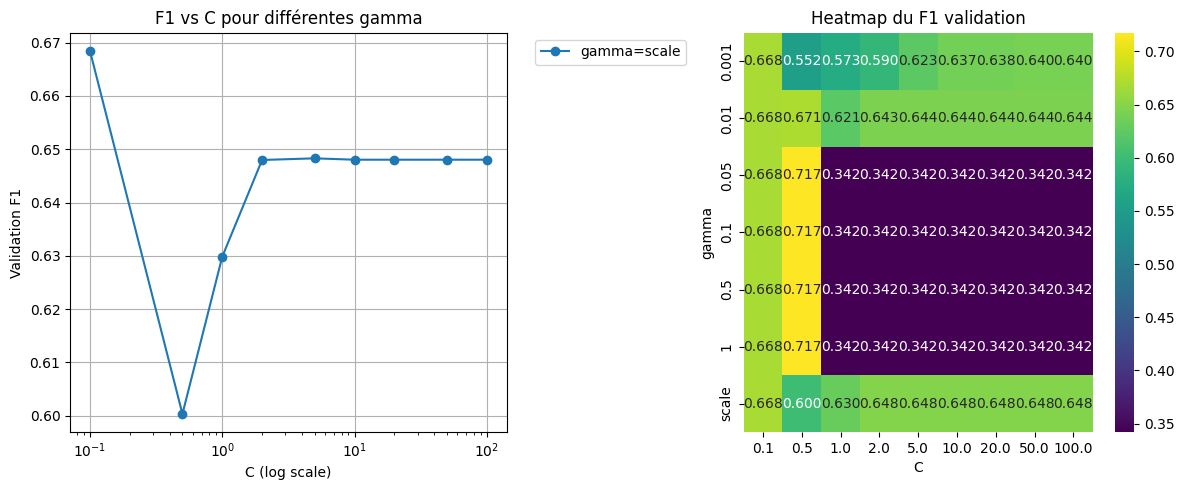

Meilleurs paramètres : {'C': 0.5, 'gamma': 0.1}
Meilleur F1 moyen (val) : 0.7173973994741601


In [23]:
plt.figure(figsize=(12, 5))

# Courbe log-log : F1 vs C, pour différentes gamma
plt.subplot(1, 2, 1)
for g in param_grid['gamma']:
    mask = results['param_gamma'] == str(g)
    if not mask.any():
        continue
    subset = results[mask].sort_values('param_C')
    plt.semilogx(subset['param_C'].astype(float), 
                 subset['mean_test_score'], 
                 marker='o', label=f'gamma={g}')
plt.xlabel('C (log scale)')
plt.ylabel('Validation F1')
plt.title('F1 vs C pour différentes gamma')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)

# Heatmap 2D (F1 en fonction de (C, gamma))
plt.subplot(1, 2, 2)
pivot = results.pivot_table(index='param_gamma', columns='param_C', 
                            values='mean_test_score')
import seaborn as sns
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='viridis')
plt.title('Heatmap du F1 validation')
plt.xlabel('C')
plt.ylabel('gamma')

plt.tight_layout()
plt.show()

# Meilleurs paramètres
print("Meilleurs paramètres :", grid.best_params_)
print("Meilleur F1 moyen (val) :", grid.best_score_)

In [27]:
# ═══════════════════════════════════════════════════════════
# Correction : ré-entraînement robuste avec validation croisée
# ═══════════════════════════════════════════════════════════

from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import f1_score, accuracy_score, roc_auc_score, classification_report, precision_recall_curve
import numpy as np

# Fusionner train et validation
X_full = np.vstack([DATASETS['D2_interact+pont']['train'], 
                    DATASETS['D2_interact+pont']['val']])
y_full = np.concatenate([y_train, y_val])

# Paramètres optimaux (C=0.5, gamma=0.1)
svm = SVC(C=0.5, kernel='rbf', gamma=0.1, 
          class_weight='balanced', probability=True, random_state=42)

# Validation croisée (5 folds)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Prédictions sur le full (pour estimer le seuil)
proba_cv = cross_val_predict(svm, X_full, y_full, cv=cv, method='predict_proba')[:, 1]

# Seuil optimal basé sur le F1 sur le full (CV)
prec, rec, th = precision_recall_curve(y_full, proba_cv)
f1_scores = 2 * prec * rec / (prec + rec + 1e-8)
best_th = th[np.argmax(f1_scores[:-1])]
print(f"Seuil optimal (CV) : {best_th:.3f} (F1 max = {np.max(f1_scores):.4f})")

# Réentraîner sur tout X_full
svm.fit(X_full, y_full)

# Prédiction sur le test
proba_test = svm.predict_proba(DATASETS['D2_interact+pont']['test'])[:, 1]
y_pred = (proba_test >= best_th).astype(int)

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, proba_test)

print("\n" + "═"*55)
print("  RÉSULTAT FINAL – SVM corrigé (C=0.5, gamma=0.1)")
print("─"*55)
print(f"  Accuracy (seuil opt.) : {acc:.4f}")
print(f"  F1-score (seuil opt.) : {f1:.4f}")
print(f"  AUC-ROC               : {auc:.4f}")
print("═"*55)
print(classification_report(y_test, y_pred, target_names=['incoherent','coherent']))

Seuil optimal (CV) : 0.491 (F1 max = 0.6677)

═══════════════════════════════════════════════════════
  RÉSULTAT FINAL – SVM corrigé (C=0.5, gamma=0.1)
───────────────────────────────────────────────────────
  Accuracy (seuil opt.) : 0.4973
  F1-score (seuil opt.) : 0.6643
  AUC-ROC               : 0.5007
═══════════════════════════════════════════════════════
              precision    recall  f1-score   support

  incoherent       0.00      0.00      0.00       754
    coherent       0.50      1.00      0.66       746

    accuracy                           0.50      1500
   macro avg       0.25      0.50      0.33      1500
weighted avg       0.25      0.50      0.33      1500



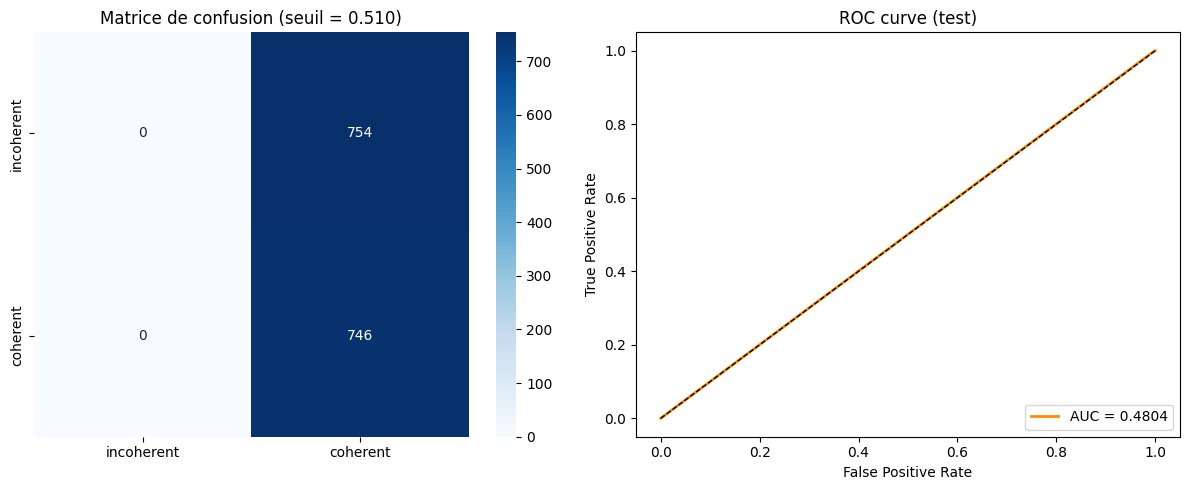

In [28]:
# Tracé de la matrice de confusion et de la courbe ROC
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['incoherent','coherent'],
            yticklabels=['incoherent','coherent'])
axes[0].set_title(f'Matrice de confusion (seuil = {best_th_acc:.3f})')

# Courbe ROC
fpr, tpr, _ = roc_curve(y_test, proba_test)
axes[1].plot(fpr, tpr, 'darkorange', lw=2, label=f'AUC = {auc_test:.4f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC curve (test)')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.savefig('svm_optimized_diagnostics.png', dpi=120, bbox_inches='tight')
plt.show()

In [ ]:
# ═══════════════════════════════════════════════════════════
# Cell 13 — Sauvegarde
# ═══════════════════════════════════════════════════════════
import joblib
joblib.dump(MODEL,   'v6_model.pkl')
joblib.dump(sc_int,  'v6_sc_int.pkl')
joblib.dump(sc_br,   'v6_sc_br.pkl')
joblib.dump(sc_cat,  'v6_sc_cat.pkl')
joblib.dump(pca_i,   'v6_pca_img.pkl')
joblib.dump(svd_t,   'v6_svd_txt.pkl')
joblib.dump(sc_i,    'v6_sc_img.pkl')
joblib.dump(sc_t,    'v6_sc_txt.pkl')
joblib.dump(tfidf,   'v6_tfidf.pkl')
joblib.dump(vt_i,    'v6_vt_img.pkl')
joblib.dump(vt_t,    'v6_vt_txt.pkl')
joblib.dump({'threshold': THRESH, 'best_dataset': best['dset'],
             'best_clf': best['clf']}, 'v6_config.pkl')
print('Sauvegarde OK.')
print(f'  Meilleur dataset : {best["dset"]}')
print(f'  Test F1          : {f1_opt:.4f}')
print(f'  AUC-ROC          : {auc:.4f}')